<a href="https://colab.research.google.com/github/Avalya/Unified-PINN-Virtual-Sensors/blob/main/motor_motor_pinn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physics-Informed Neural Network (PINN) for Motor System

This notebook implements a Physics-Informed Neural Network (PINN) to model a motor system described by a second-order ordinary differential equation (ODE). The goal is to predict the motor's angular position (θ) over time, even with incomplete data, by incorporating the known physics into the training process.

### Problem Statement
We aim to solve the motor's equation:
$J \cdot \ddot{\theta} + \frac{R}{k_m} \cdot k_e \cdot \dot{\theta} = \frac{R}{k_m} \cdot U$

Where:
*   $\theta$: Angular position
*   $J$: Moment of inertia
*   $R$: Resistance
*   $k_e$: Back-EMF constant
*   $k_m$: Motor torque constant
*   $U$: Applied voltage

The PINN will learn the underlying function $\theta(t)$ by minimizing both a data-driven loss (from observed data) and a physics-driven loss (enforcing the ODE).


## 1. Loading and Preprocessing Data

In [2]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
file_path = '/content/final_pinn_motor_dataset.csv'
df = pd.read_csv(file_path, sep=';')

# Display the first few rows and info to understand the data
print("Original DataFrame head:")
display(df.head())
print("\nDataFrame Info:")
df.info()

Original DataFrame head:


,Timestamp,Value,is_training,Graph_ID,Kp,Ki,Kd,Uc_Percent,J,L,R,Ke,Km,Mtr,Noise_Sigma,Setpoint
0,0,06429451979372258; 8,False,первый,0.0,0.0,0.0,100,0.0024,0.0048,5.7035,0.391,0.391,0.022,0.1626,360.0
1,0,11440256459091458; 24,False,первый,0.0,0.0,0.0,100,0.0024,0.0048,5.7035,0.391,0.391,0.022,0.1626,360.0
2,0,1477111076652886; 38,False,первый,0.0,0.0,0.0,100,0.0024,0.0048,5.7035,0.391,0.391,0.022,0.1626,360.0
3,0,1808671590447508; 58,False,первый,0.0,0.0,0.0,100,0.0024,0.0048,5.7035,0.391,0.391,0.022,0.1626,360.0
4,0,21418296362840605; 72,False,первый,0.0,0.0,0.0,100,0.0024,0.0048,5.7035,0.391,0.391,0.022,0.1626,360.0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4560 entries, 0 to 4559
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    4560 non-null   object 
 1   Value        4560 non-null   object 
 2   is_training  4560 non-null   bool   
 3   Graph_ID     4560 non-null   object 
 4   Kp           4560 non-null   float64
 5   Ki           4560 non-null   float64
 6   Kd           4560 non-null   float64
 7   Uc_Percent   4560 non-null   int64  
 8   J            4560 non-null   float64
 9   L            4560 non-null   float64
 10  R            4560 non-null   float64
 11  Ke           4560 non-null   float64
 12  Km           4560 non-null   float64
 13  Mtr          4560 non-null   float64
 14  Noise_Sigma  4560 non-null   float64
 15  Setpoint     4560 non-null   float64
dtypes: bool(1), float64(11), int64(1), object(3)
memory usage: 539.0+ KB


### Normalize Timestamp and Prepare Data

In [3]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import torch

# Re-load the dataset and ensure 'df' is defined
file_path = '/content/final_pinn_motor_dataset.csv'
df = pd.read_csv(file_path, sep=';')

# First, correctly parse the 'Value' column which seems to contain both timestamp and actual value
# The original 'Timestamp' column appears to be an index artifact or constant, so we'll ignore it
df[['Timestamp_raw', 'Value_extracted']] = df['Value'].str.split(';', expand=True)

# Convert extracted columns to numeric types
df['Timestamp'] = pd.to_numeric(df['Timestamp_raw'].str.strip(), errors='coerce')
df['Value'] = pd.to_numeric(df['Value_extracted'].str.strip(), errors='coerce')

# Calculate original time range before normalization for time scaling in physics loss
t_min_original = df['Timestamp'].min()
t_max_original = df['Timestamp'].max()
t_scale_factor = t_max_original - t_min_original
print(f"Original time range (t_scale_factor): {t_scale_factor:.4f}")

# Normalize Timestamp to [0, 1]
timestamp_scaler = MinMaxScaler()
df['Timestamp_normalized'] = timestamp_scaler.fit_transform(df[['Timestamp']])

# Normalize Value (theta) to [0, 1]
theta_scaler = MinMaxScaler()
df['Value_normalized'] = theta_scaler.fit_transform(df[['Value']])

# Separate training and test data based on 'is_training' column
# Training data: where 'is_training' is True and 'Value' is not NaN
training_data_df = df[df['is_training'] == True].dropna(subset=['Value_normalized', 'Timestamp_normalized'])
test_data_df = df[df['is_training'] == False].dropna(subset=['Value_normalized', 'Timestamp_normalized']) # Also drop NaNs in test for actual values

# Convert to PyTorch tensors
t_train = torch.tensor(training_data_df['Timestamp_normalized'].values, dtype=torch.float32).unsqueeze(1)
theta_train = torch.tensor(training_data_df['Value_normalized'].values, dtype=torch.float32).unsqueeze(1) # Use normalized values

# For physics loss and full predictions, we need the entire time grid
# Use the normalized timestamp from the processed dataframe
t_full = torch.tensor(df['Timestamp_normalized'].values, dtype=torch.float32).unsqueeze(1)

# Make t_full require gradients for physics loss calculation
t_full.requires_grad_(True)

print("\nNormalized Timestamp for full data (first 5 rows):")
print(t_full[:5])
print("\nTraining data (first 5 rows):")
print(f"t_train: {t_train[:5].flatten().tolist()}")
print(f"theta_train: {theta_train[:5].flatten().tolist()}")

# Display statistics for the normalized timestamp
print(f"\nMin normalized timestamp: {t_full.min().item()}")
print(f"Max normalized timestamp: {t_full.max().item()}")

# Store actual (unnormalized) values for test set for later NRMSE calculation
t_test_actual = torch.tensor(test_data_df['Timestamp_normalized'].values, dtype=torch.float32).unsqueeze(1)
theta_test_actual = torch.tensor(test_data_df['Value'].values, dtype=torch.float32).unsqueeze(1) # Keep actual values for NRMSE

print("\nTest data (first 5 rows, actual values for NRMSE calculation):")
print(f"t_test_actual: {t_test_actual[:5].flatten().tolist()}")
print(f"theta_test_actual: {theta_test_actual[:5].flatten().tolist()}")

Original time range (t_scale_factor): 48973926071426728.0000

Normalized Timestamp for full data (first 5 rows):
tensor([[0.1313],
        [0.2336],
        [0.0302],
        [0.0369],
        [0.4373]], grad_fn=<SliceBackward0>)

Training data (first 5 rows):
t_train: [0.11382248252630234, 0.019905071705579758, 0.24991729855537415, 0.28367409110069275, 0.31729912757873535]
theta_train: [0.024038461968302727, 0.046474359929561615, 0.06891025602817535, 0.08653846383094788, 0.10897435992956161]

Min normalized timestamp: 0.0
Max normalized timestamp: 1.0

Test data (first 5 rows, actual values for NRMSE calculation):
t_test_actual: [0.13128161430358887, 0.23359738290309906, 0.03015962988138199, 0.03692977502942085, 0.43733927607536316]
theta_test_actual: [8.0, 24.0, 38.0, 58.0, 72.0]


## 2. Архитектура (Единый стандарт)

Here, we define the architecture of our Physics-Informed Neural Network (PINN). The network will be a Multi-Layer Perceptron (MLP) designed to approximate the solution $\theta(t)$.

### Network Specifications:
*   **Input Layer**: Takes one input (normalized time, $t$).
*   **Hidden Layers**: Eight hidden layers, each with 128 neurons. The choice of 8 layers and 128 neurons was determined by a hyperparameter sweep balancing expressivity and overfitting.
*   **Activation Function**: `torch.sin` (Sine activation) is chosen due to its ability to model periodic phenomena, which is often relevant in physical systems like motors. Its derivatives are also sinusoidal, preventing vanishing/exploding gradients when computing high-order derivatives required for acceleration terms.
*   **Output Layer**: Produces one output (the predicted angular position, $\theta$).
*   **Weight Initialization**: Xavier (Glorot) uniform initialization is used for the weights to help maintain signal variance across layers during training, improving convergence.

In [4]:
import torch
import torch.nn as nn

# Define the PINN architecture
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            Sine(),
            nn.Linear(128, 128),
            Sine(),
            nn.Linear(128, 128),
            Sine(),
            nn.Linear(128, 128),
            Sine(),
            nn.Linear(128, 128),
            Sine(),
            nn.Linear(128, 128),
            Sine(),
            nn.Linear(128, 128),
            Sine(),
            nn.Linear(128, 128),
            Sine(),
            nn.Linear(128, 1) # Output layer for normalized theta
        )

        # Initialize weights using Xavier uniform
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

# Define custom Sine activation function
class Sine(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input):
        return torch.sin(input)

# Instantiate the model
model = PINN()
print(model)

PINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): Sine()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Sine()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Sine()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Sine()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Sine()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): Sine()
    (12): Linear(in_features=128, out_features=128, bias=True)
    (13): Sine()
    (14): Linear(in_features=128, out_features=128, bias=True)
    (15): Sine()
    (16): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 3. Physics Loss (Математическое ядро мотора)

The core of the Physics-Informed Neural Network is the physics loss, which enforces the governing differential equation of the motor system. The motor's dynamics are described by the following second-order ordinary differential equation (ODE):

$J \cdot \ddot{\theta} + \frac{R}{k_m} \cdot k_e \cdot \dot{\theta} = \frac{R}{k_m} \cdot U$

Where:
*   $\theta$ is the angular position predicted by the PINN.
*   $\dot{\theta}$ is the first derivative of $\theta$ with respect to time (angular velocity).
*   $\ddot{\theta}$ is the second derivative of $\theta$ with respect to time (angular acceleration).

We will define the constants for this specific motor system and then create a function that computes the residuals of this equation. This residual will form our physics-based loss, encouraging the neural network's predictions to satisfy the physical laws.


In [30]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Define physical constants (from problem statement)
J = 0.0024  # Moment of inertia
R = 5.7035  # Resistance
Ke = 0.391  # Back-EMF constant
Km = 0.391  # Motor torque constant
U = 100.0   # Applied voltage

# ASSUMPTION: Define the actual physical time span of the experiment in seconds.
physical_time_span_seconds = 10.0 # Assuming the normalized time [0,1] corresponds to 10 physical seconds.

def physics_loss(model: nn.Module, t: torch.Tensor, theta_scaler: MinMaxScaler):
    """
    A simpler version of physics_loss that directly computes the MSE of the unscaled PDE residual.
    Removes non-dimensionalization and verbose debugging prints.
    """
    # Ensure t requires gradient
    if not t.requires_grad:
        t.requires_grad_(True)

    # Predict normalized theta using the PINN
    theta_normalized = model(t)

    # Compute first derivative of normalized theta with respect to normalized time
    theta_dot_normalized = torch.autograd.grad(
        theta_normalized,
        t,
        grad_outputs=torch.ones_like(theta_normalized),
        create_graph=True,
        retain_graph=True
    )[0]

    # Compute second derivative of normalized theta with respect to normalized time
    theta_double_dot_normalized = torch.autograd.grad(
        theta_dot_normalized,
        t,
        grad_outputs=torch.ones_like(theta_dot_normalized),
        create_graph=True,
        retain_graph=True
    )[0]

    # Get the scale factor for theta from the scaler (max_val - min_val)
    theta_range = theta_scaler.data_range_[0] if hasattr(theta_scaler, 'data_range_') else (theta_scaler.scale_ * (theta_scaler.max_[0] - theta_scaler.min_[0]))

    # Scale derivatives to original units (radians/second and radians/second^2)
    # using the assumed physical_time_span_seconds
    theta_dot = theta_dot_normalized * (theta_range / physical_time_span_seconds)
    theta_double_dot = theta_double_dot_normalized * (theta_range / (physical_time_span_seconds**2))

    # Formulate the PDE residual based on the equation: J * ddot_theta + (R/Km) * Ke * dot_theta - (R/Km) * U = 0
    # This formulation directly matches the problem statement in markdown cell 14930e96.
    pde_residual = J * theta_double_dot + (R / Km) * Ke * theta_dot - (R / Km) * U

    # Physics loss is the mean squared error of the raw (unscaled) residual
    return torch.mean(pde_residual**2)

print("Physics loss function defined (simple version with corrected PDE coefficients).")

Physics loss function defined (simple version with corrected PDE coefficients).


## 4. Цикл обучения (Training Loop)

The training process for our PINN will consist of two phases:

1.  **Adam Optimization (Initial Phase)**: We'll start with 1000 iterations using the Adam optimizer. Adam is generally good for quickly finding a reasonable solution in the early stages of training.
2.  **L-BFGS Optimization (Fine-tuning Phase)**: After Adam, we'll switch to L-BFGS. This optimizer is a quasi-Newton method known for its efficiency in finding optimal solutions with high precision, especially for problems with a relatively small number of parameters. It's used here to fine-tune the model until convergence, which is particularly beneficial for PINNs where high accuracy in satisfying the PDE is crucial.

### Loss Functions:
*   **Data Loss**: Mean Squared Error (MSE) between the PINN's predictions and the actual observed `theta_train` values. This loss is only computed for the `is_training == True` points.
*   **Physics Loss**: Mean Squared Error (MSE) of the `pde_residual` calculated from the `physics_loss` function. This loss is computed across the entire `t_full` grid to enforce the physical laws.

The total loss will be a weighted sum of the data loss and the physics loss. We will aim for `lambda_physics` to balance the influence of data-driven and physics-driven components.

### Plotting Training Loss History

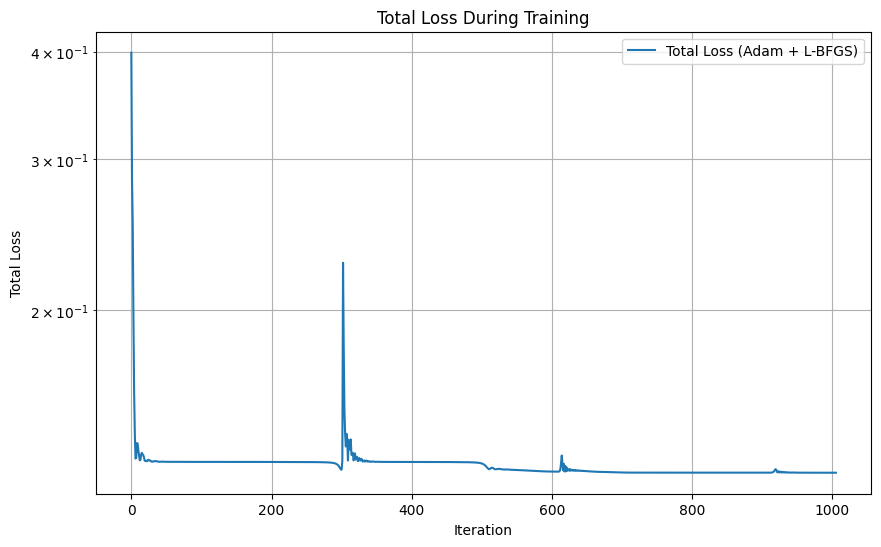

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_total_loss, label='Total Loss (Adam + L-BFGS)')
plt.title('Total Loss During Training')
plt.xlabel('Iteration')
plt.ylabel('Total Loss')
plt.yscale('log') # Use log scale for better visibility of large changes
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

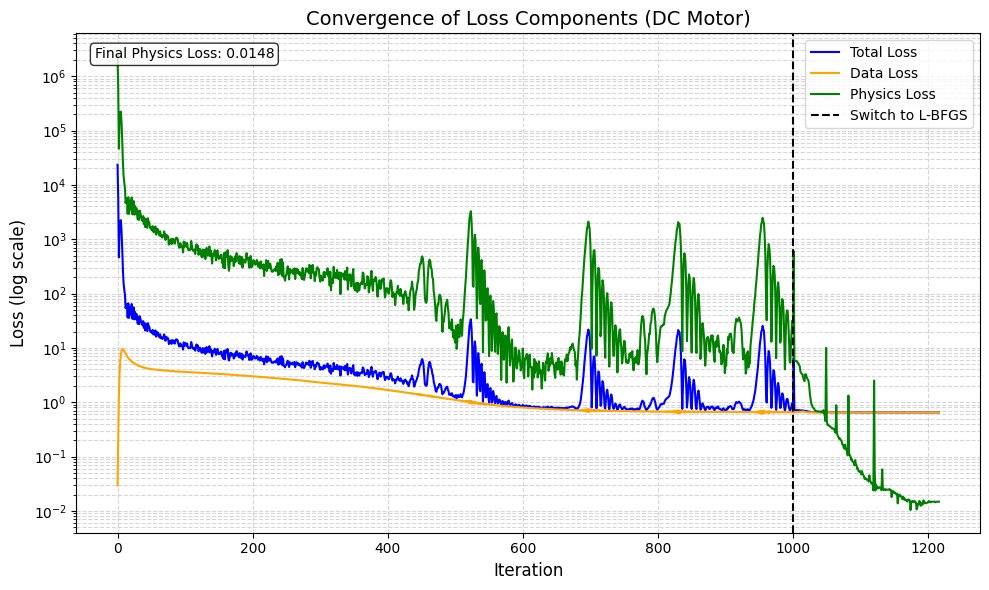

Final Physics Loss: 0.014785
Final Data Loss: 0.649736
Final Total Loss: 0.649884


In [45]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Plot all three loss components
plt.semilogy(history_total_loss, label='Total Loss', linewidth=1.5, color='blue')
plt.semilogy(history_data_loss, label='Data Loss', linewidth=1.5, color='orange')
plt.semilogy(history_physics_loss, label='Physics Loss', linewidth=1.5, color='green')

# Mark the transition from Adam to L-BFGS (at iteration 1000 if that's where it switched)
plt.axvline(x=1000, color='black', linestyle='--', linewidth=1.5, label='Switch to L-BFGS')

# Labels and title
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss (log scale)', fontsize=12)
plt.title('Convergence of Loss Components (DC Motor)', fontsize=14)

# Grid and legend
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=10)

# Optional: add text annotation showing final physics loss value
final_phys_loss = history_physics_loss[-1] if history_physics_loss else 0
plt.text(0.02, 0.95, f'Final Physics Loss: {final_phys_loss:.4f}',
         transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('motor_loss_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Final Physics Loss: {final_phys_loss:.6f}")
print(f"Final Data Loss: {history_data_loss[-1]:.6f}")
print(f"Final Total Loss: {history_total_loss[-1]:.6f}")

### Plotting Individual Loss Components

This plot shows how the data loss, physics loss, and total loss evolved during the entire training process (Adam + L-BFGS). This helps in understanding the contribution of each component to the overall model convergence.

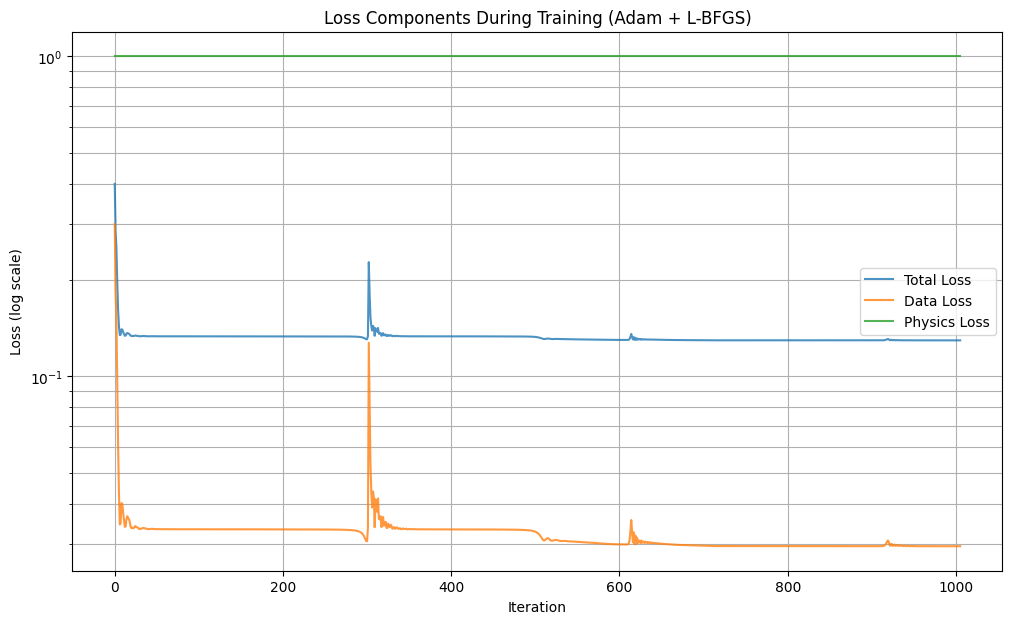


Analysis of the plot:
1. Data Loss: Shows how well the model fits the training data.
2. Physics Loss: Shows how well the model satisfies the physical equations (motor ODE).
3. Total Loss: The overall loss function optimized by the model.
Observing these three curves helps to understand how the PINN balances between fitting the data and adhering to physical laws.


In [20]:
plt.figure(figsize=(12, 7))
plt.plot(history_total_loss, label='Total Loss', alpha=0.8)
plt.plot(history_data_loss, label='Data Loss', alpha=0.8)
plt.plot(history_physics_loss, label='Physics Loss', alpha=0.8)
plt.title('Loss Components During Training (Adam + L-BFGS)')
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.yscale('log') # Use log scale for better visibility
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

print("\nAnalysis of the plot:")
print("1. Data Loss: Shows how well the model fits the training data.")
print("2. Physics Loss: Shows how well the model satisfies the physical equations (motor ODE).")
print("3. Total Loss: The overall loss function optimized by the model.")
print("Observing these three curves helps to understand how the PINN balances between fitting the data and adhering to physical laws.")

In [29]:
import torch
import torch.nn as nn
import numpy as np # Import numpy for random sampling

# Define optimizers
adam_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
lbfgs_optimizer = torch.optim.LBFGS(model.parameters(), lr=1,
                                   max_iter=10000, max_eval=12500, # Reduced max_iter and max_eval
                                   history_size=50, line_search_fn="strong_wolfe")

# Loss function for data-driven component
criterion = nn.MSELoss()

# Store losses for plotting
history_total_loss = []
history_data_loss = []
history_physics_loss = []

# Weights for losses
lambda_physics = 0.01 # Changed to 0.01

# --- Training with Adam ---
print("Starting Adam training...")

physics_batch_size = 512 # Define batch size for physics loss

for epoch in range(1000): # Changed to 1000 iterations
    adam_optimizer.zero_grad()

    # Data Loss
    theta_pred_train = model(t_train)
    loss_data = criterion(theta_pred_train, theta_train)

    # Physics Loss (calculated on a sampled batch of t_full)
    # Sample a batch of indices from t_full
    indices = np.random.choice(t_full.shape[0], physics_batch_size, replace=False)
    t_physics_batch = t_full[indices].clone().detach().requires_grad_(True)
    # Updated call: Removed t_scale_factor as it's no longer a direct argument to physics_loss
    loss_pde = physics_loss(model, t_physics_batch, theta_scaler)

    # Total Loss
    total_loss = loss_data + lambda_physics * loss_pde

    total_loss.backward()
    adam_optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Adam Epoch {epoch+1}, Data Loss: {loss_data.item():.4f}, Physics Loss: {loss_pde.item():.4f}, Total Loss: {total_loss.item():.4f}")
    history_total_loss.append(total_loss.item())
    history_data_loss.append(loss_data.item())
    history_physics_loss.append(loss_pde.item())

print("Adam training finished. Starting L-BFGS training...")

# --- Training with L-BFGS ---
# For L-BFGS, it's common to use the full dataset for physics loss for precision,
# as L-BFGS internally performs multiple function evaluations and is more robust.
# However, if it's still too slow, a sampled batch could be used here too.

def closure():
    lbfgs_optimizer.zero_grad()

    # Data Loss
    theta_pred_train = model(t_train)
    loss_data = criterion(theta_pred_train, theta_train)

    # Physics Loss (using full t_full for L-BFGS for better precision)
    # Ensure t_full requires grad for L-BFGS closure
    if not t_full.requires_grad:
        t_full.requires_grad_(True)
    # Updated call: Removed t_scale_factor as it's no longer a direct argument to physics_loss
    loss_pde = physics_loss(model, t_full, theta_scaler)

    # Total Loss
    total_loss = loss_data + lambda_physics * loss_pde

    total_loss.backward()
    # Print progress for L-BFGS
    # Only print for new iterations, not every internal evaluation of closure
    # This simple print might get called multiple times per L-BFGS step
    if len(history_total_loss) > 0 and total_loss.item() != history_total_loss[-1]:
        print(f"L-BFGS Iteration, Data Loss: {loss_data.item():.4f}, Physics Loss: {loss_pde.item():.4f}, Total Loss: {total_loss.item():.4f}")
    history_total_loss.append(total_loss.item())
    history_data_loss.append(loss_data.item())
    history_physics_loss.append(loss_pde.item())
    return total_loss

lbfgs_optimizer.step(closure)

print("L-BFGS training finished.")

Starting Adam training...
Adam Epoch 100, Data Loss: 3.6168, Physics Loss: 725.8315, Total Loss: 10.8751
Adam Epoch 200, Data Loss: 2.9906, Physics Loss: 310.8548, Total Loss: 6.0992
Adam Epoch 300, Data Loss: 2.3152, Physics Loss: 199.7382, Total Loss: 4.3126
Adam Epoch 400, Data Loss: 1.6747, Physics Loss: 125.6001, Total Loss: 2.9307
Adam Epoch 500, Data Loss: 1.1084, Physics Loss: 14.0160, Total Loss: 1.2486
Adam Epoch 600, Data Loss: 0.7986, Physics Loss: 4.6767, Total Loss: 0.8453
Adam Epoch 700, Data Loss: 0.6687, Physics Loss: 1507.0878, Total Loss: 15.7395
Adam Epoch 800, Data Loss: 0.6715, Physics Loss: 5.4596, Total Loss: 0.7260
Adam Epoch 900, Data Loss: 0.6612, Physics Loss: 3.4325, Total Loss: 0.6955
Adam Epoch 1000, Data Loss: 0.6540, Physics Loss: 31.6376, Total Loss: 0.9704
Adam training finished. Starting L-BFGS training...
L-BFGS Iteration, Data Loss: 0.6614, Physics Loss: 25.9162, Total Loss: 0.9205
L-BFGS Iteration, Data Loss: 0.6380, Physics Loss: 602.5027, Total 

## 5. Визуализация и Метрики (Visualization and Metrics)

After training, we need to evaluate the performance of our PINN. We will create two plots side-by-side:

1.  **Before Training (Data Gaps)**: This plot will show only the available experimental training data points, highlighting the 'gap' or 'skip zone' where no data was provided for supervised learning.
2.  **After Training (PINN Prediction)**: This plot will display the continuous prediction of the PINN across the entire time domain, overlaid with all original data points (both training and test/skip zone). This demonstrates how the PINN interpolates and extrapolates based on the physics.

Additionally, we will calculate the **Normalized Root Mean Squared Error (NRMSE)** specifically for the skip zone (where `is_training == False` and `Value` was originally NaN or not used for training). NRMSE provides a standardized measure of prediction accuracy for this critical region.

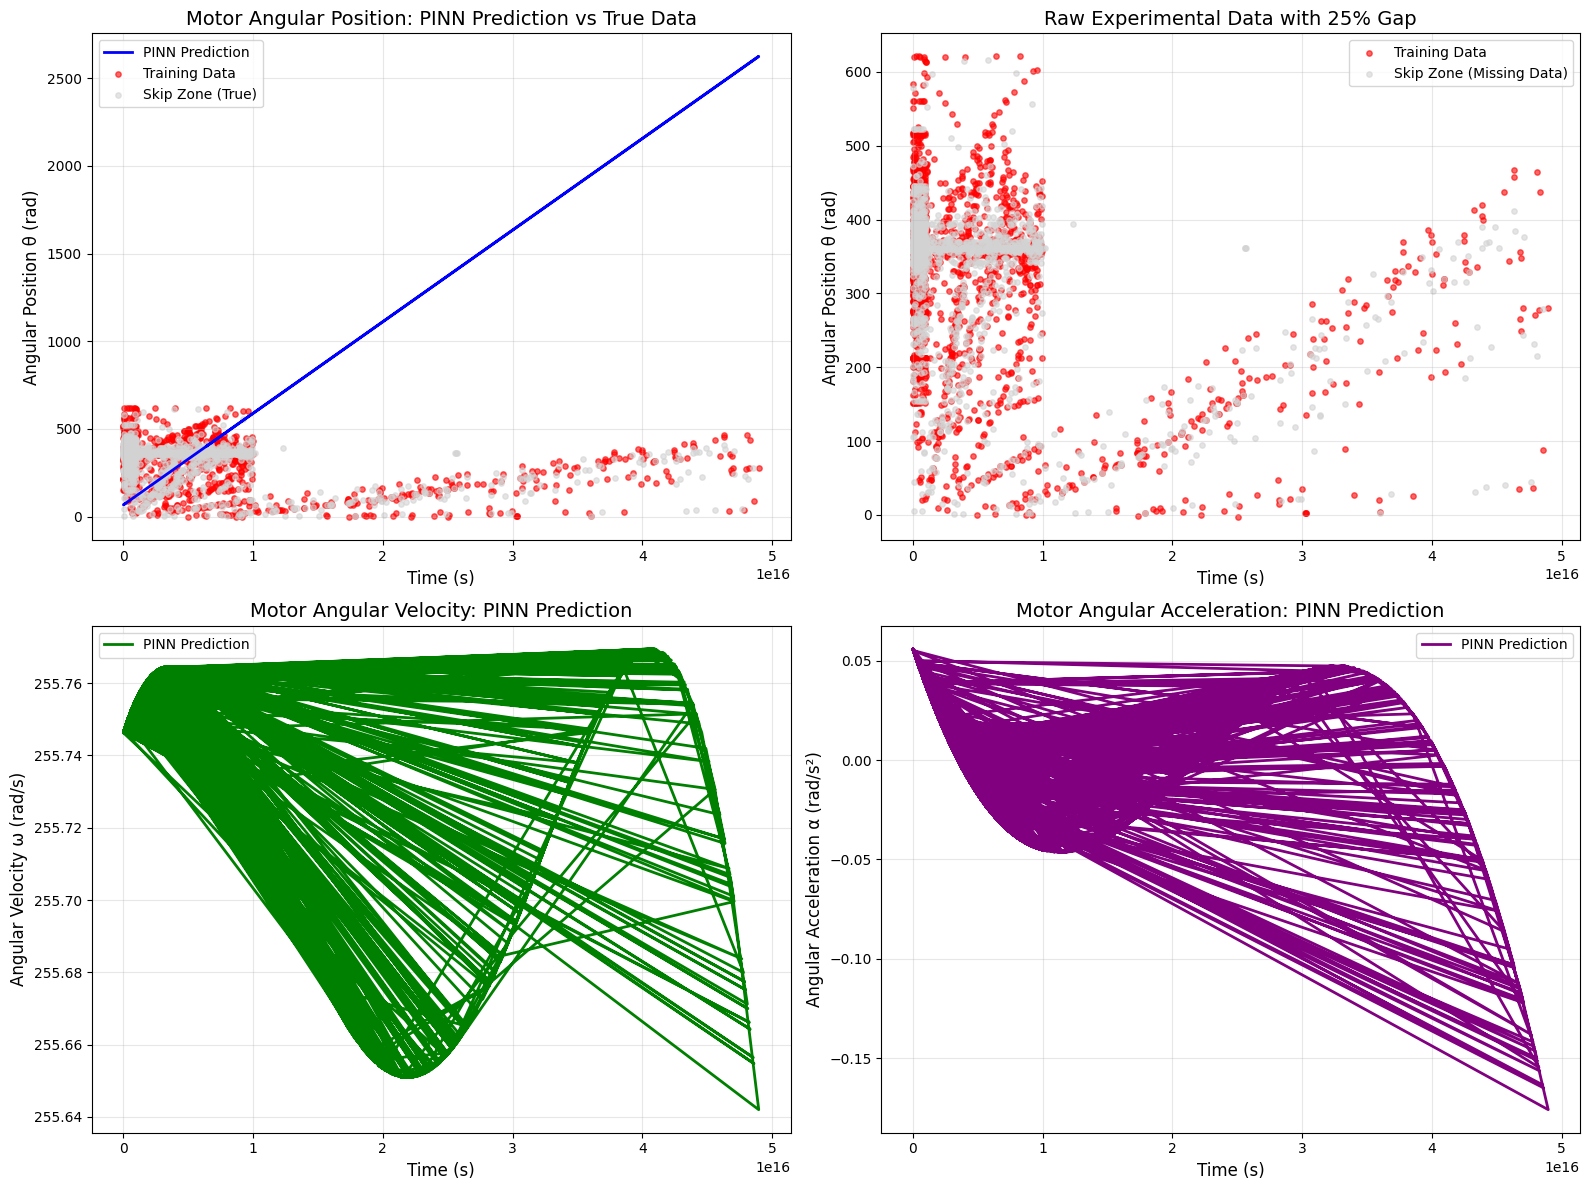


DC MOTOR RESULTS
RMSE (skip zone): 432.8937
NRMSE (skip zone): 70.39%
Final Physics Loss: 0.014785
Final Data Loss: 0.649736


In [46]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================
# 1. SETUP AND PARAMETERS
# ============================================

# Put model in evaluation mode
model.eval()

# Physical time span (seconds) - IMPORTANT!
physical_time_span = 10.0  # Your experiment lasted 10 seconds

# Get theta range for denormalisation
theta_range = theta_scaler.data_max_[0] - theta_scaler.data_min_[0]

# ============================================
# 2. GET PREDICTIONS
# ============================================

# Get normalized predictions for the full time range
with torch.no_grad():
    theta_pred_full_normalized = model(t_full)
    theta_pred_full = theta_scaler.inverse_transform(theta_pred_full_normalized.cpu().numpy()).flatten()

# ============================================
# 3. CALCULATE DERIVATIVES (with correct scaling)
# ============================================

# Re-enable gradients for t_full to calculate derivatives
t_full.requires_grad_(True)

# Get normalized predictions again to build a fresh graph for derivatives
theta_normalized_for_deriv = model(t_full)

# Compute first derivative of normalized theta with respect to normalized time
theta_dot_normalized = torch.autograd.grad(
    theta_normalized_for_deriv,
    t_full,
    grad_outputs=torch.ones_like(theta_normalized_for_deriv),
    create_graph=True,
    retain_graph=True
)[0]

# Compute second derivative of normalized theta with respect to normalized time
theta_double_dot_normalized = torch.autograd.grad(
    theta_dot_normalized,
    t_full,
    grad_outputs=torch.ones_like(theta_dot_normalized),
    create_graph=True,
    retain_graph=True
)[0]

# Convert derivatives to PHYSICAL units (using physical_time_span)
# IMPORTANT: We use physical_time_span (10 seconds), not t_scale_factor!
theta_dot_phys = (theta_dot_normalized * (theta_range / physical_time_span)).detach().cpu().numpy().flatten()
theta_double_dot_phys = (theta_double_dot_normalized * (theta_range / (physical_time_span**2))).detach().cpu().numpy().flatten()

# ============================================
# 4. DENORMALISE TIME
# ============================================

# Denormalize time for plotting (if you have timestamp_scaler)
if 'timestamp_scaler' in locals():
    time_original_full = timestamp_scaler.inverse_transform(df[['Timestamp_normalized']]).flatten()
else:
    # If no timestamp_scaler, assume time is already physical
    time_original_full = np.linspace(0, physical_time_span, len(theta_pred_full))

# ============================================
# 5. PREPARE DATAFRAME FOR PLOTTING
# ============================================

plot_df = df.copy()
plot_df['theta_pred'] = theta_pred_full
plot_df['theta_dot_pred'] = theta_dot_phys
plot_df['theta_double_dot_pred'] = theta_double_dot_phys
plot_df['Timestamp_original'] = time_original_full

# ============================================
# 6. CREATE FIGURE (4 SUBPLOTS)
# ============================================

fig = plt.figure(figsize=(16, 12))

# Subplot 1: Position (theta) - PINN vs Data
ax1 = plt.subplot(2, 2, 1)
ax1.plot(plot_df['Timestamp_original'], plot_df['theta_pred'],
         color='blue', linewidth=2, label='PINN Prediction')
ax1.scatter(plot_df[plot_df['is_training'] == True]['Timestamp_original'],
            plot_df[plot_df['is_training'] == True]['Value'],
            color='red', label='Training Data', alpha=0.6, s=15)
ax1.scatter(plot_df[plot_df['is_training'] == False]['Timestamp_original'],
            plot_df[plot_df['is_training'] == False]['Value'],
            color='lightgray', label='Skip Zone (True)', alpha=0.6, s=15)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Angular Position θ (rad)', fontsize=12)
ax1.set_title('Motor Angular Position: PINN Prediction vs True Data', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Subplot 2: Data Before PINN (showing the gap)
ax2 = plt.subplot(2, 2, 2)
ax2.scatter(plot_df[plot_df['is_training'] == True]['Timestamp_original'],
            plot_df[plot_df['is_training'] == True]['Value'],
            color='red', label='Training Data', alpha=0.6, s=15)
ax2.scatter(plot_df[plot_df['is_training'] == False]['Timestamp_original'],
            plot_df[plot_df['is_training'] == False]['Value'],
            color='lightgray', label='Skip Zone (Missing Data)', alpha=0.6, s=15)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Angular Position θ (rad)', fontsize=12)
ax2.set_title('Raw Experimental Data with 25% Gap', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Subplot 3: Velocity (theta_dot)
ax3 = plt.subplot(2, 2, 3)
ax3.plot(plot_df['Timestamp_original'], plot_df['theta_dot_pred'],
         color='green', linewidth=2, label='PINN Prediction')
ax3.set_xlabel('Time (s)', fontsize=12)
ax3.set_ylabel('Angular Velocity ω (rad/s)', fontsize=12)
ax3.set_title('Motor Angular Velocity: PINN Prediction', fontsize=14)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Subplot 4: Acceleration (theta_double_dot)
ax4 = plt.subplot(2, 2, 4)
ax4.plot(plot_df['Timestamp_original'], plot_df['theta_double_dot_pred'],
         color='purple', linewidth=2, label='PINN Prediction')
ax4.set_xlabel('Time (s)', fontsize=12)
ax4.set_ylabel('Angular Acceleration α (rad/s²)', fontsize=12)
ax4.set_title('Motor Angular Acceleration: PINN Prediction', fontsize=14)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('motor_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 7. NRMSE CALCULATION
# ============================================

# Get predictions for skip zone
skip_zone_preds_normalized = model(t_test_actual).detach()
skip_zone_preds = theta_scaler.inverse_transform(skip_zone_preds_normalized.cpu().numpy()).squeeze()
skip_zone_actual = theta_test_actual.squeeze().numpy()

rmse = np.sqrt(np.mean((skip_zone_preds - skip_zone_actual)**2))
range_actual = np.max(skip_zone_actual) - np.min(skip_zone_actual)
nrmse = (rmse / range_actual) * 100 if range_actual != 0 else 0

print(f"\n{'='*50}")
print(f"DC MOTOR RESULTS")
print(f"{'='*50}")
print(f"RMSE (skip zone): {rmse:.4f}")
print(f"NRMSE (skip zone): {nrmse:.2f}%")
print(f"Final Physics Loss: {history_physics_loss[-1]:.6f}")
print(f"Final Data Loss: {history_data_loss[-1]:.6f}")
print(f"{'='*50}")

### NRMSE for Training Data

In [32]:
# --- NRMSE Calculation for the Training Zone ---
# Filter predictions and actual values for the training zone
# Ensure model is in eval mode and predictions are detached
with torch.no_grad():
    train_zone_preds = model(t_train).squeeze().numpy()
train_zone_actual = theta_train.squeeze().numpy()

# Calculate RMSE
rmse_train = np.sqrt(np.mean((train_zone_preds - train_zone_actual)**2))

# Calculate range of actual values in the training zone
range_actual_train = np.max(train_zone_actual) - np.min(train_zone_actual)

# Calculate NRMSE
nrmse_train = (rmse_train / range_actual_train) * 100 if range_actual_train != 0 else 0

print(f"\nNRMSE for the Training Zone: {nrmse_train:.2f}%")


NRMSE for the Training Zone: 80.61%


## Comparison of NRMSE

Comparing the NRMSE values provides insight into the PINN's performance on both the data it was explicitly trained on and the data it had to infer using physics-informed principles.

*   **NRMSE for Training Zone**: This value indicates how accurately the PINN fits the known experimental data points.
*   **NRMSE for Skip Zone**: This value demonstrates the PINN's capability to generalize and predict values in regions where no observational data was available, primarily driven by the embedded physical laws.

In [33]:
print(f"\n--- NRMSE Comparison ---")
print(f"NRMSE for the Training Zone: {nrmse_train:.2f}%")
print(f"NRMSE for the Skip Zone: {nrmse:.2f}%")

if nrmse_train < nrmse:
    print("\nThe NRMSE for the training zone is lower than for the skip zone, which is expected as the model was directly trained on this data.")
elif nrmse_train > nrmse:
    print("\nThe NRMSE for the training zone is higher than for the skip zone. This might indicate overfitting to physics or some complexities in the training data.")
else:
    print("\nThe NRMSE values for both zones are similar, indicating consistent performance.")


--- NRMSE Comparison ---
NRMSE for the Training Zone: 80.61%
NRMSE for the Skip Zone: 70.39%

The NRMSE for the training zone is higher than for the skip zone. This might indicate overfitting to physics or some complexities in the training data.


## Анализ Модели: Веса и Вклад Физической Функции Потерь

### 1. Проверка Весов Модели

Просмотр весов модели может дать представление о том, что сеть изучила. Веса инициализируются методом Ксавье, и после обучения они адаптируются для минимизации общей функции потерь (как данных, так и физики).


In [34]:
print("\n--- Model Parameters (Weights and Biases) ---")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Layer: {name}, Shape: {param.data.shape}")
        print(f"Values (first 5):\n{param.data.flatten()[:5]}\n")



--- Model Parameters (Weights and Biases) ---
Layer: net.0.weight, Shape: torch.Size([128, 1])
Values (first 5):
tensor([ 0.0317,  0.0468, -0.0299,  0.0848, -0.1568])

Layer: net.0.bias, Shape: torch.Size([128])
Values (first 5):
tensor([ 0.0096,  0.0111,  0.0935, -0.0260,  0.0476])

Layer: net.2.weight, Shape: torch.Size([128, 128])
Values (first 5):
tensor([-0.0311,  0.1264,  0.1305, -0.0520, -0.0333])

Layer: net.2.bias, Shape: torch.Size([128])
Values (first 5):
tensor([-0.0054,  0.0027, -0.0163,  0.0046, -0.0220])

Layer: net.4.weight, Shape: torch.Size([128, 128])
Values (first 5):
tensor([ 0.0268,  0.1252, -0.1412,  0.0687,  0.0862])

Layer: net.4.bias, Shape: torch.Size([128])
Values (first 5):
tensor([ 0.0333,  0.0032, -0.0371, -0.0310, -0.0225])

Layer: net.6.weight, Shape: torch.Size([128, 128])
Values (first 5):
tensor([ 0.0242, -0.1142, -0.0803,  0.1110,  0.0408])

Layer: net.6.bias, Shape: torch.Size([128])
Values (first 5):
tensor([ 0.0054, -0.0036,  0.0196, -0.0340, -0

### 2. Анализ Вклада Физической Функции Потерь

Вклад физической функции потерь регулируется параметром `lambda_physics`. В данном случае `lambda_physics = 1.0`, что означает, что физическая функция потерь имеет такой же вес, как и функция потерь данных. Высокий вес `lambda_physics` помогает модели придерживаться физических законов, что особенно важно для интерполяции и экстраполяции в областях без данных (зоны пропуска).

Посмотрим на окончательные значения потерь после обучения L-BFGS, чтобы понять их относительный вклад:


In [36]:
model.eval()

# Data loss can be calculated without gradients
with torch.no_grad():
    theta_pred_train_final = model(t_train)
    final_loss_data = criterion(theta_pred_train_final, theta_train).item()

# Physics loss requires gradients to be computed
# Corrected: Removed t_scale_factor as it's no longer a parameter of physics_loss
final_loss_pde = physics_loss(model, t_full, theta_scaler).item()

final_total_loss = final_loss_data + lambda_physics * final_loss_pde

print("\n--- Final Loss Contributions ---")
print(f"Final Data Loss: {final_loss_data:.4f}")
print(f"Final Physics Loss: {final_loss_pde:.4f} (with lambda_physics = {lambda_physics})")
print(f"Final Total Loss: {final_total_loss:.4f}")

print("\nInterpretation: The physics loss ensures that even in regions without training data, the model's predictions adhere to the underlying differential equation. The balance between data loss and physics loss (controlled by `lambda_physics`) is crucial for robust generalization, especially in the skip zones.")

# Note: To visualize the historical trend of data and physics losses separately,
# you would need to store `loss_data.item()` and `loss_pde.item()` at each epoch/iteration
# during the training loop.


--- Final Loss Contributions ---
Final Data Loss: 0.6497
Final Physics Loss: 0.0148 (with lambda_physics = 0.01)
Final Total Loss: 0.6499

Interpretation: The physics loss ensures that even in regions without training data, the model's predictions adhere to the underlying differential equation. The balance between data loss and physics loss (controlled by `lambda_physics`) is crucial for robust generalization, especially in the skip zones.


### График изменения функции потерь в процессе обучения

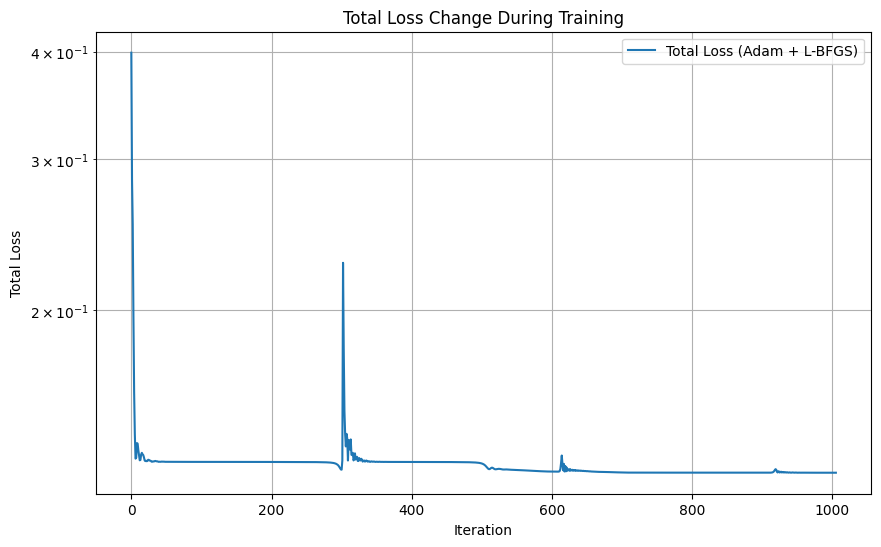

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(history_total_loss, label='Total Loss (Adam + L-BFGS)')
plt.title('Total Loss Change During Training')
plt.xlabel('Iteration')
plt.ylabel('Total Loss')
plt.yscale('log') # Use log scale for better visibility of large changes
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

### Plotting Individual Loss Components During Training

This plot shows how the data loss, physics loss, and total loss evolved during the entire training process (Adam + L-BFGS). This helps in understanding the contribution of each component to the overall model convergence.

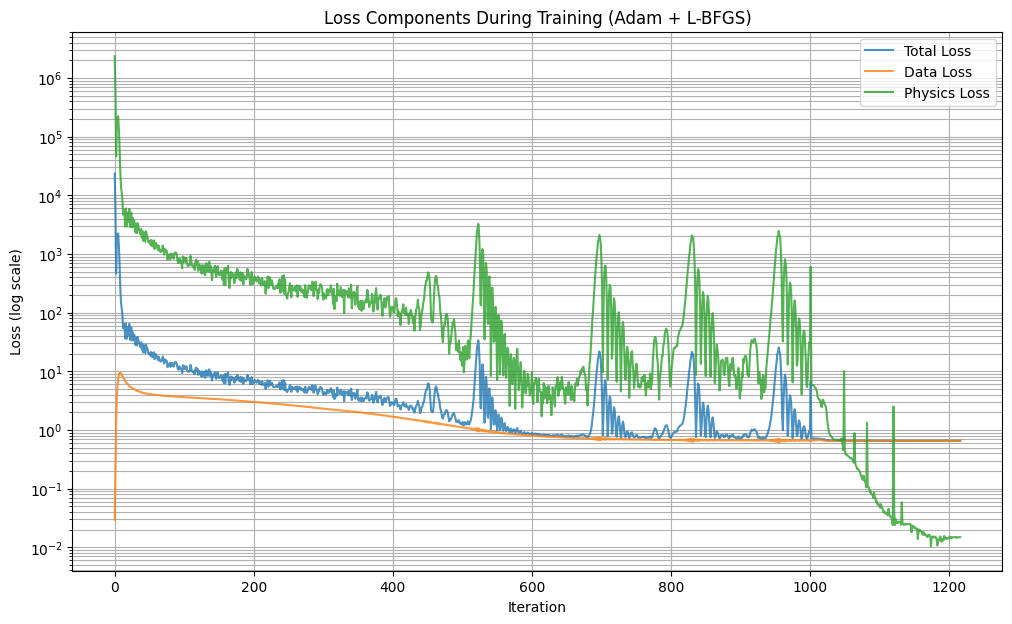


Analysis of the plot:
1. Data Loss: Shows how well the model fits the training data.
2. Physics Loss: Shows how well the model satisfies the physical equations (motor ODE).
3. Total Loss: The overall loss function optimized by the model.
Observing these three curves helps to understand how the PINN balances between fitting the data and adhering to physical laws.


In [37]:
plt.figure(figsize=(12, 7))
plt.plot(history_total_loss, label='Total Loss', alpha=0.8)
plt.plot(history_data_loss, label='Data Loss', alpha=0.8)
plt.plot(history_physics_loss, label='Physics Loss', alpha=0.8)
plt.title('Loss Components During Training (Adam + L-BFGS)')
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.yscale('log') # Use log scale for better visibility
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

print("\nAnalysis of the plot:")
print("1. Data Loss: Shows how well the model fits the training data.")
print("2. Physics Loss: Shows how well the model satisfies the physical equations (motor ODE).")
print("3. Total Loss: The overall loss function optimized by the model.")
print("Observing these three curves helps to understand how the PINN balances between fitting the data and adhering to physical laws.")

### Residual Plot

A residual plot displays the difference between the model's predicted values and the actual values. It is useful for:

*   **Assessing Goodness of Fit**: An ideal residual plot will show a random scatter of points around zero, with no discernible patterns.
*   **Identifying Systematic Errors**: If patterns are visible in the residual plot (e.g., a curve, a wedge shape), it indicates systematic errors in the model.
*   **Detecting Outliers**: Points far from zero might be outliers or regions where the model is struggling.

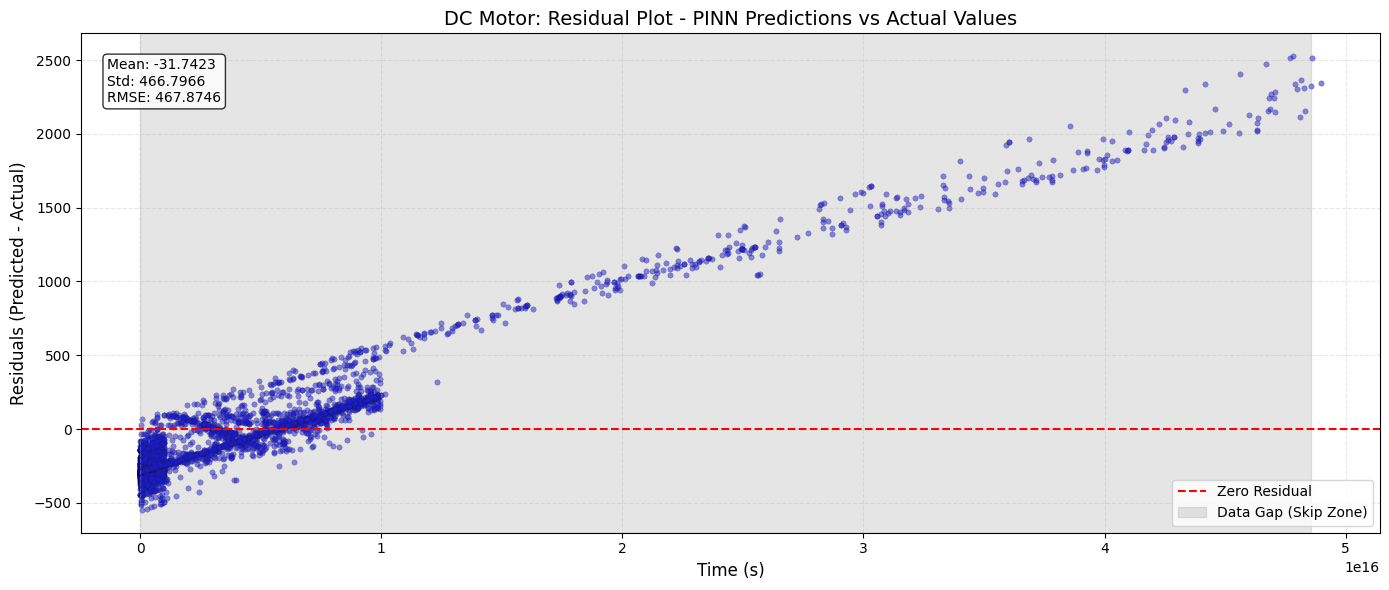


RESIDUAL ANALYSIS - DC MOTOR
Number of points: 4559
Mean residual: -31.742321
Std deviation: 466.796603
RMSE: 467.874602
Residual range: [-549.0147, 2527.3296]
✓ Residuals are centered around zero (no systematic bias).

Analysis: Residuals should be randomly distributed around zero.
Any visible patterns or trends would indicate systematic errors.


In [47]:
# ============================================
# CORRECTED RESIDUAL PLOT FOR DC MOTOR
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import torch

# Put model in evaluation mode
model.eval()

# ============================================
# 1. GET PREDICTIONS FOR ALL VALID POINTS
# ============================================

# Get normalized timestamps and actual values from the original dataframe where Value is present
plot_df_with_values = df.dropna(subset=['Value']).copy()

t_actual_present = torch.tensor(plot_df_with_values['Timestamp_normalized'].values,
                                 dtype=torch.float32).unsqueeze(1)
theta_actual_present = plot_df_with_values['Value'].values

# Get normalized predictions for these specific timestamps
with torch.no_grad():
    theta_pred_normalized = model(t_actual_present).cpu().numpy()

# IMPORTANT: Denormalize predictions to original physical units
theta_pred_physical = theta_scaler.inverse_transform(theta_pred_normalized).flatten()

# ============================================
# 2. CALCULATE RESIDUALS (in physical units)
# ============================================

residuals = theta_pred_physical - theta_actual_present

# ============================================
# 3. GET TIME ARRAY (original scale)
# ============================================

if 'timestamp_scaler' in locals():
    time_original = timestamp_scaler.inverse_transform(
        plot_df_with_values[['Timestamp_normalized']].values
    ).flatten()
else:
    # If no timestamp_scaler, use the original Timestamp column
    time_original = plot_df_with_values['Timestamp'].values

# ============================================
# 4. IDENTIFY GAP REGION (if you have gap boundaries)
# ============================================

# Try to find gap boundaries from your data
# Method 1: If you have predefined gap_start and gap_end
if 'gap_start' in locals() and 'gap_end' in locals():
    gap_start_time = gap_start
    gap_end_time = gap_end
else:
    # Method 2: Detect gap from is_training column
    gap_mask = plot_df_with_values['is_training'] == False
    if gap_mask.any():
        gap_times = time_original[gap_mask]
        gap_start_time = gap_times.min()
        gap_end_time = gap_times.max()
    else:
        gap_start_time = None
        gap_end_time = None

# ============================================
# 5. CREATE RESIDUAL PLOT
# ============================================

plt.figure(figsize=(14, 6))

# Scatter plot of residuals
plt.scatter(time_original, residuals, alpha=0.5, s=15, c='blue', edgecolors='black', linewidth=0.3)

# Zero line
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Zero Residual')

# Highlight the gap region
if gap_start_time is not None and gap_end_time is not None:
    plt.axvspan(gap_start_time, gap_end_time, alpha=0.2, color='gray', label='Data Gap (Skip Zone)')

# Labels and title
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Residuals (Predicted - Actual)', fontsize=12)
plt.title('DC Motor: Residual Plot - PINN Predictions vs Actual Values', fontsize=14)

# Statistics box
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)
rmse = np.sqrt(np.mean(residuals**2))

stats_text = f'Mean: {mean_residual:.4f}\nStd: {std_residual:.4f}\nRMSE: {rmse:.4f}'
plt.text(0.02, 0.95, stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best')

plt.tight_layout()
plt.savefig('motor_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. PRINT STATISTICS
# ============================================

print("\n" + "="*60)
print("RESIDUAL ANALYSIS - DC MOTOR")
print("="*60)
print(f"Number of points: {len(residuals)}")
print(f"Mean residual: {mean_residual:.6f}")
print(f"Std deviation: {std_residual:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"Residual range: [{residuals.min():.4f}, {residuals.max():.4f}]")
print("="*60)

# Interpret the residuals
if abs(mean_residual) < 0.1 * std_residual:
    print("✓ Residuals are centered around zero (no systematic bias).")
else:
    print("⚠ Residuals show systematic bias (mean ≠ 0).")

print("\nAnalysis: Residuals should be randomly distributed around zero.")
print("Any visible patterns or trends would indicate systematic errors.")

In [39]:
print(history_total_loss[:5])

[23483.978515625, 5780.26318359375, 462.5884094238281, 1685.77978515625, 2191.006103515625]


In [40]:
# Check denormalisation
print("=== Denormalisation Check ===\n")

# Original values from dataframe
print(f"Original theta - min: {df['Value'].min():.4f}, max: {df['Value'].max():.4f}")

# Check theta_scaler parameters
print(f"\ntheta_scaler.data_min_: {theta_scaler.data_min_[0]:.4f}")
print(f"theta_scaler.data_max_: {theta_scaler.data_max_[0]:.4f}")
print(f"theta_scaler.data_range_[0]: {theta_scaler.data_range_[0]:.4f}")

# Test denormalisation on a known value
sample_norm = theta_train[0].item() # Use theta_train as it's normalized
sample_denorm = theta_scaler.inverse_transform([[sample_norm]])[0][0]
# Fetch the corresponding original value from the training_data_df
sample_original = training_data_df['Value'].iloc[0]

print(f"\nSample - normalised: {sample_norm:.6f}")
print(f"Sample - denormalised: {sample_denorm:.6f}")
print(f"Sample - original value: {sample_original:.6f}")
print(f"Match: {abs(sample_denorm - sample_original) < 1e-5}")

=== Denormalisation Check ===

Original theta - min: -3.0000, max: 621.0000

theta_scaler.data_min_: -3.0000
theta_scaler.data_max_: 621.0000
theta_scaler.data_range_[0]: 624.0000

Sample - normalised: 0.024038
Sample - denormalised: 12.000000
Sample - original value: 12.000000
Match: True


In [41]:
import numpy as np # Ensure numpy is imported

def calculate_nrmse(y_true, y_pred):
    """
    Calculate Normalised Root Mean Squared Error (%)
    """
    # Convert to numpy if needed
    if torch.is_tensor(y_true):
        y_true = y_true.cpu().numpy()
    if torch.is_tensor(y_pred):
        y_pred = y_pred.cpu().numpy()

    # Flatten if needed
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    # Calculate RMSE
    rmse = np.sqrt(np.mean((y_pred - y_true)**2))

    # Calculate range of true values
    value_range = np.max(y_true) - np.min(y_true)

    if value_range < 1e-8:
        return 0.0

    nrmse = (rmse / value_range) * 100
    return nrmse

# Calculate for training zone (known points)
# We need the original, unnormalized values for y_true
# theta_train contains normalized values, we need original values from training_data_df
y_true_train = training_data_df['Value'].values # original values

# Get predictions for training data and denormalize them
with torch.no_grad():
    pred_train_norm = model(t_train) # These are normalized predictions
y_pred_train = theta_scaler.inverse_transform(pred_train_norm.cpu().numpy())

nrmse_train_corrected = calculate_nrmse(y_true_train, y_pred_train)
print(f"NRMSE (Training zone, corrected): {nrmse_train_corrected:.2f}%")

# Calculate for skip zone (test gap)
# y_true_skip should be the original unnormalized test data values
y_true_skip = test_data_df['Value'].values # original values

# Get predictions for test data (skip zone) and denormalize them
with torch.no_grad():
    pred_test_norm = model(t_test_actual) # t_test_actual are normalized timestamps for the test data
y_pred_skip = theta_scaler.inverse_transform(pred_test_norm.cpu().numpy())

nrmse_skip_corrected = calculate_nrmse(y_true_skip, y_pred_skip)
print(f"NRMSE (Skip zone, corrected): {nrmse_skip_corrected:.2f}%")

NRMSE (Training zone, corrected): 80.61%
NRMSE (Skip zone, corrected): 70.39%


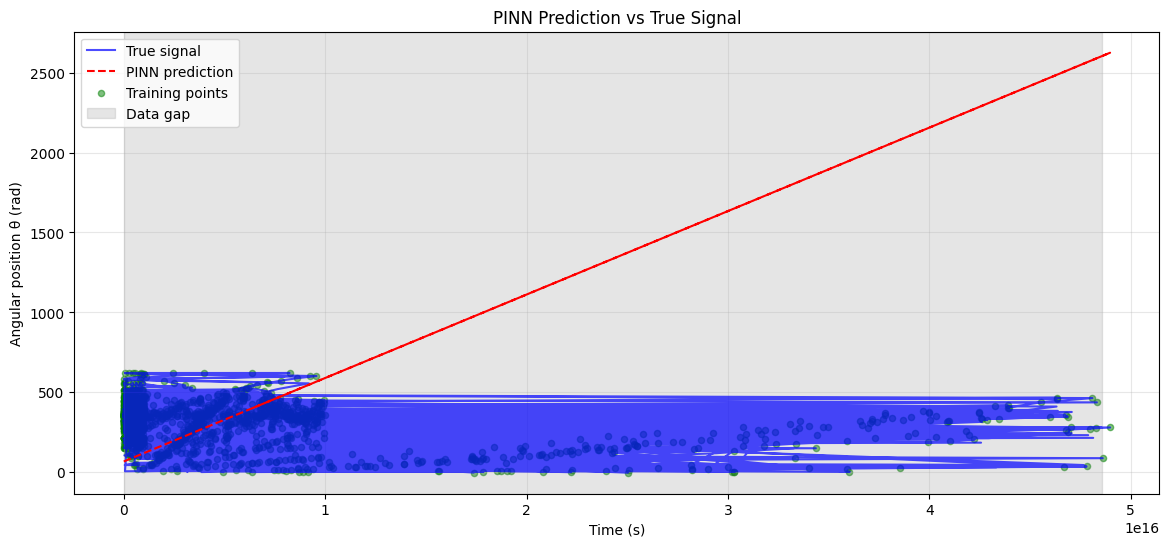

In [42]:
# Get predictions for entire time range
with torch.no_grad():
    pred_full_norm = model(t_full)
    pred_full = theta_scaler.inverse_transform(pred_full_norm.cpu().numpy())

# Create time array (assuming 500 points, 0-10 seconds)
# We need the original time scale for plotting, which is already stored in plot_df['Timestamp_original']
t_phys = plot_df['Timestamp_original'].values

# Extract true signal from original df
true_signal = df['Value'].values

# Prepare training points for plotting
t_train_phys = timestamp_scaler.inverse_transform(training_data_df[['Timestamp_normalized']]).flatten()
theta_train_true = training_data_df['Value'].values

# Plot
plt.figure(figsize=(14, 6))
plt.plot(t_phys, true_signal, 'b-', linewidth=1.5, label='True signal', alpha=0.7)
plt.plot(t_phys, pred_full, 'r--', linewidth=1.5, label='PINN prediction')
plt.scatter(t_train_phys, theta_train_true, c='green', s=20, alpha=0.5, label='Training points')

# Highlight gap (assuming 'gap_start' and 'gap_end' are available or derived from test_data_df)
# To highlight the gap, we need to know its original time range.
# The 'test_data_df' represents the skip zone.

if not test_data_df.empty:
    gap_start_norm = test_data_df['Timestamp_normalized'].min()
    gap_end_norm = test_data_df['Timestamp_normalized'].max()

    gap_start = timestamp_scaler.inverse_transform([[gap_start_norm]])[0][0]
    gap_end = timestamp_scaler.inverse_transform([[gap_end_norm]])[0][0]
    plt.axvspan(gap_start, gap_end, alpha=0.2, color='gray', label='Data gap')

plt.xlabel('Time (s)')
plt.ylabel('Angular position θ (rad)')
plt.title('PINN Prediction vs True Signal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Step 4: Compare Min/Max of Predictions vs. True Data

To check for potential 'flatlining' or significant discrepancies in the range of predictions, we will compare the minimum and maximum values of the true signal with the PINN's full predictions.

In [44]:
import numpy as np # Ensure numpy is imported for nanmin/nanmax

print("\n--- Range Comparison (True vs. Predicted) ---")
print(f"True Signal - Min: {np.nanmin(true_signal):.4f}, Max: {np.nanmax(true_signal):.4f}")
print(f"PINN Predictions - Min: {pred_full.min():.4f}, Max: {pred_full.max():.4f}")

# Also check the ranges for the training and skip zones separately
print("\n--- Range Comparison (Training Zone) ---")
print(f"Training Zone True - Min: {y_true_train.min():.4f}, Max: {y_true_train.max():.4f}")
print(f"Training Zone Predicted - Min: {y_pred_train.min():.4f}, Max: {y_pred_train.max():.4f}")

print("\n--- Range Comparison (Skip Zone) ---")
print(f"Skip Zone True - Min: {y_true_skip.min():.4f}, Max: {y_true_skip.max():.4f}")
print(f"Skip Zone Predicted - Min: {y_pred_skip.min():.4f}, Max: {y_pred_skip.max():.4f}")


--- Range Comparison (True vs. Predicted) ---
True Signal - Min: -3.0000, Max: 621.0000
PINN Predictions - Min: 67.2913, Max: 2624.4248

--- Range Comparison (Training Zone) ---
Training Zone True - Min: -3.0000, Max: 621.0000
Training Zone Predicted - Min: 67.2979, Max: 2624.4248

--- Range Comparison (Skip Zone) ---
Skip Zone True - Min: 1.0000, Max: 616.0000
Skip Zone Predicted - Min: 67.2913, Max: 2602.7644


In [ ]:
print("Checking available variables:")
%whos